# TensorDSLab readout quickstart

This notebook takes the shortest public path from binned photoelectron truth to simulated readout products. We will define a small detector geometry, load a provisional readout profile, run one simulation, and look at the resulting charge and waveforms.

Before you start, run `./create_environment.sh`, activate the environment with `conda activate tensor_dslab`, and select that environment as the notebook kernel. Everything here runs on the CPU. The `ds20k_veto` profile is a useful example, but it is not an approved detector calibration.

## The complete workflow at a glance

Once you have a `Photoelectrons` field and its `SampleAxis`, getting a digitized readout takes only two public calls:

```python
config = ds20k_veto(sample_axis=sample_axis)

readout = simulate_readout(
    photoelectrons,
    products=(DigitizedWaveform,),
    config=config,
    rng=Threefry4x32(seed=17),
)
```

Asking for `DigitizedWaveform` automatically runs everything needed to produce it, while the returned collection keeps only the product you requested. In the walkthrough below, we will also keep the intermediate products so we can see what happens at each stage.

## 1. Import what we need

In [1]:
import torch
import matplotlib.pyplot as plt

from tensor_core import Threefry4x32

from tensor_dslab import (
    AnalogWaveform,
    ChannelAxis,
    Charge,
    DigitizedWaveform,
    ExampleAxis,
    NoiseWaveform,
    Photoelectrons,
    PureWaveform,
    SampleAxis,
    quantity,
    simulate_readout,
)
from tensor_dslab.readout.profiles import ds20k_veto

print(f"Python/Torch active: {torch.__version__}; default device: {torch.empty(()).device}")

Python/Torch active: 2.13.0; default device: cpu


## 2. Define the geometry and input photoelectrons

TensorDSLab fields pair a tensor with semantic axes. We will use one example, one detector channel, and 5,000 time samples at 2 ns intervals, giving us a 10 μs window. The tensor shape is `(example, channel, sample)`.

The four nonzero cells represent deposits of 1, 2, 3, and 4 photoelectrons. `Photoelectrons` is already-binned input truth from an upstream stage, so TensorDSLab uses it as-is rather than regenerating or normalizing it.

In [2]:
example_axis = ExampleAxis(count=1)
channel_axis = ChannelAxis(labels=("veto-0",))
sample_axis = SampleAxis.from_period(
    period=quantity(2, "ns"),
    count=5000,
)

axes = (example_axis, channel_axis, sample_axis)

counts = torch.zeros(
    tuple(axis.size for axis in axes),
    dtype=torch.int64,
    device="cpu",
)

deposits = (
    (100, 1),
    (1300, 2),
    (2500, 3),
    (3700, 4),
)

for index, value in deposits:
    counts[0, 0, index] = value

photoelectrons = Photoelectrons(tensor=counts, axes=axes)

photoelectrons

Photoelectrons(tensor=tensor([[[0, 0, 0,  ..., 0, 0, 0]]]), axes=(ExampleAxis(count=1), ChannelAxis(labels=('veto-0',)), SampleAxis(start=0, step=2000, count=5000)))

## 3. Load a readout profile

A `ReadoutConfig` describes the physical models used to produce charge and waveforms. The provisional `ds20k_veto` profile gives us a complete example for the axes above. It needs the exact sample axis because its pulse response is stored as a sampled kernel. Passing the example and channel axes also makes those dimensions available if a profile kernel needs to vary across them.

For this quickstart, loading the profile is all we need. Building every configuration component by hand can be covered separately.

In [3]:
config = ds20k_veto(
    sample_axis=sample_axis,
    channel_axis=channel_axis,
    example_axis=example_axis,
)

{
    "charge": type(config.charge).__name__,
    "pure_waveform": type(config.pure_waveform).__name__,
    "noise_waveform": type(config.noise_waveform).__name__,
    "analog_waveform": type(config.analog_waveform).__name__,
    "digitized_waveform": type(config.digitized_waveform).__name__,
}

{'charge': 'ChargeConfig',
 'pure_waveform': 'PureWaveformConfig',
 'noise_waveform': 'NoiseWaveformConfig',
 'analog_waveform': 'AnalogWaveformConfig',
 'digitized_waveform': 'DigitizedWaveformConfig'}

## 4. Simulate the requested products

Now we can call `simulate_readout`, the main public entry point. We give it the input field, the products we want back, the profile, an addressed random-number generator, and the floating-point dtype for generated fields.

The seed makes this stochastic example exactly repeatable. TensorCore's addressed `Threefry4x32` generator does not consume or modify PyTorch's global RNG state. The returned collection is keyed by field type, so we can retrieve a product with a call such as `readout.field(Charge)`.

In [4]:
requested = (
    Photoelectrons,
    Charge,
    PureWaveform,
    NoiseWaveform,
    AnalogWaveform,
    DigitizedWaveform,
)

rng = Threefry4x32(seed=17)
global_before = torch.random.get_rng_state().clone()

readout = simulate_readout(
    photoelectrons,
    products=requested,
    config=config,
    rng=rng,
    floating_dtype=torch.float32,
)

assert torch.equal(torch.random.get_rng_state(), global_before)

tuple(
    (
        field_type.__name__,
        tuple(field.tensor.shape),
        str(field.tensor.dtype),
        field.tensor.device.type,
    )
    for field_type, field in readout.fields.items()
)

(('Photoelectrons', (1, 1, 5000), 'torch.int64', 'cpu'),
 ('Charge', (1, 1, 5000), 'torch.float32', 'cpu'),
 ('PureWaveform', (1, 1, 5000), 'torch.float32', 'cpu'),
 ('NoiseWaveform', (1, 1, 5000), 'torch.float32', 'cpu'),
 ('AnalogWaveform', (1, 1, 5000), 'torch.float32', 'cpu'),
 ('DigitizedWaveform', (1, 1, 5000), 'torch.int32', 'cpu'))

## 5. See how the products fit together

Here is what came back and how the pieces fit together:

- `Photoelectrons` is the original binned truth input.
- `Charge` contains the simulated avalanche charge. It can include seeded dark counts in addition to the original deposits.
- `PureWaveform` is the signed pulse response generated from `Charge`.
- `NoiseWaveform` is the independently generated electronics-noise contribution.
- `AnalogWaveform` is the elementwise sum of the pure and noise waveforms.
- `DigitizedWaveform` contains the integer ADC codes produced from the analog signal.

The two assertions below check that analog composition is exact before digitization and that the returned `Photoelectrons` object is the same object we passed in.

In [5]:
charge = readout.field(Charge).tensor[0, 0]
pure = readout.field(PureWaveform).tensor[0, 0]
noise = readout.field(NoiseWaveform).tensor[0, 0]
analog = readout.field(AnalogWaveform).tensor[0, 0]
digitized = readout.field(DigitizedWaveform).tensor[0, 0]

assert torch.equal(analog, pure + noise)
assert readout.field(Photoelectrons) is photoelectrons

int(torch.count_nonzero(charge))

7

## 6. Compare the waveform stages

Finally, let us look at the waveform chain. `PureWaveform` is the voltage response produced by the simulated charge, while `NoiseWaveform` shows the electronics noise on its own. `AnalogWaveform` combines the two, and the final panel shows the ADC codes after digitization.

The faint black markers in the pure, analog, and digitized panels show where `Charge` is nonzero; their height does not represent the charge magnitude. TensorDSLab keeps the product data in tensors throughout the simulation. We convert the plotted slices to ordinary CPU lists only when handing them to Matplotlib.

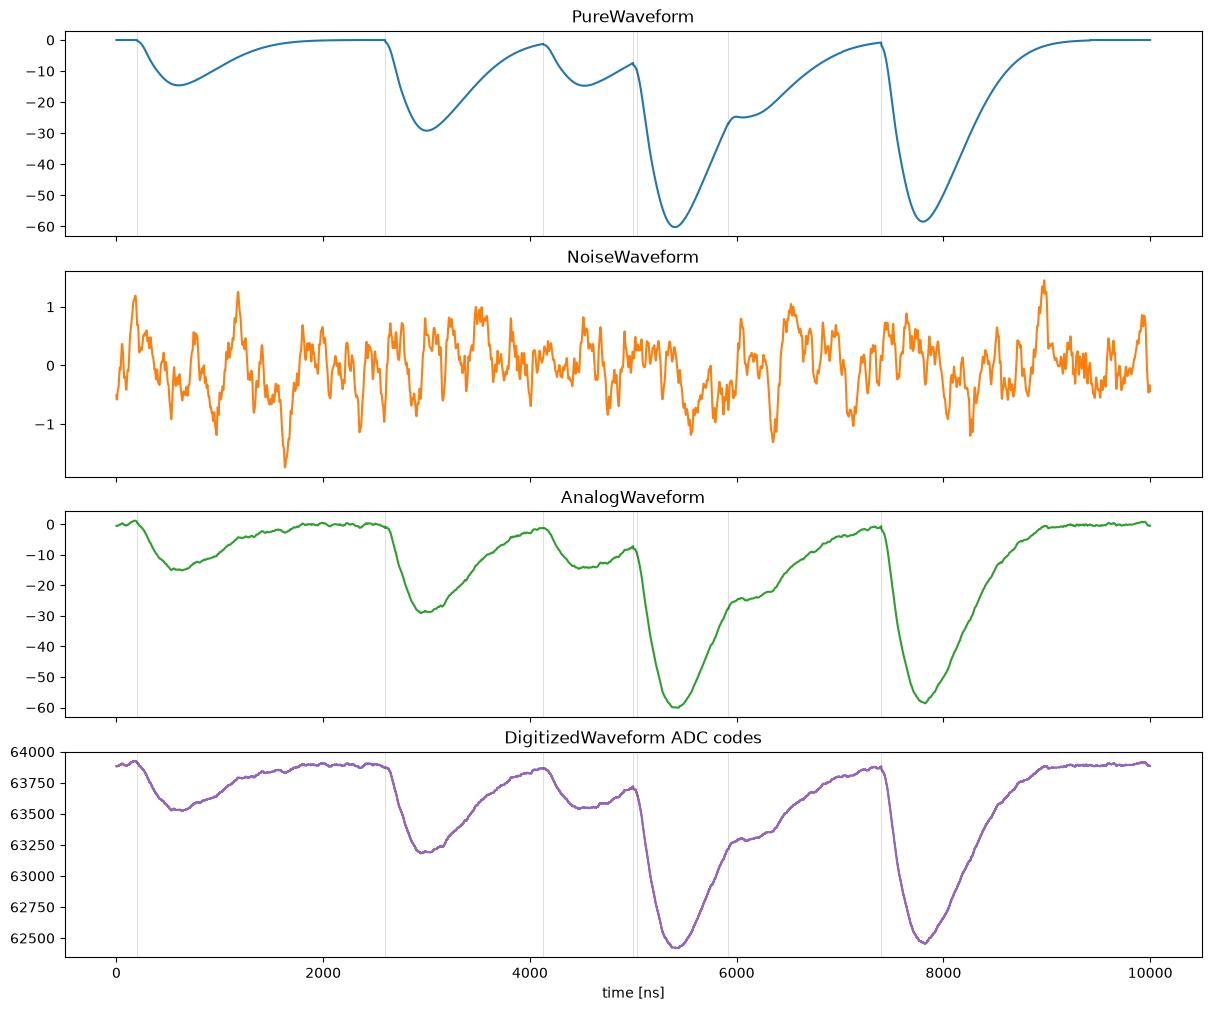

In [6]:
time_ns = [2.0 * index for index in range(sample_axis.count)]

charge_sample_indices = (
    torch.nonzero(charge > 0, as_tuple=False)
    .flatten()
    .to(device="cpu")
    .tolist()
)

pure_values = pure.to(device="cpu").tolist()
noise_values = noise.to(device="cpu").tolist()
analog_values = analog.to(device="cpu").tolist()
digitized_values = digitized.to(device="cpu").tolist()

figure, panels = plt.subplots(
    4,
    1,
    figsize=(12, 10),
    sharex=True,
    constrained_layout=True,
)

panels[0].plot(time_ns, pure_values, color="tab:blue")
panels[0].set_title("PureWaveform")

panels[1].plot(time_ns, noise_values, color="tab:orange")
panels[1].set_title("NoiseWaveform")

panels[2].plot(time_ns, analog_values, color="tab:green")
panels[2].set_title("AnalogWaveform")

panels[3].step(
    time_ns,
    digitized_values,
    where="post",
    color="tab:purple",
)
panels[3].set_title("DigitizedWaveform ADC codes")

for panel in (panels[0], panels[2], panels[3]):
    for index in charge_sample_indices:
        panel.axvline(time_ns[index], color="black", alpha=0.15, linewidth=0.6)

panels[-1].set_xlabel("time [ns]")

plt.show()